In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cupy as cp
import igpu, pickle

In [12]:
save = np.zeros((9, 10, 10, 4, 2))
for ri in range(1, 10):
    for ni in range(4):
        for si in range(10):
            data_id = str(si + 40 + (ni + 1) * 1000)
            x = igpu.open_csv_nonull("t3000/gen_n500_k5_l50_t3000_seed" + data_id + ".csv")
            for i in range(10):
                model = igpu.solve(x.T, 20, 50, z_th=x.min(), random_seed=(ni+1)*1000+i*100+ri*10+si, corr_max=ri*0.1, comp_rate=0.1)
                c = model.reconstruction_cost()
                save[ri-1, si, i, ni, :] = [model.k, c]
                print("corr={:.1f}, data_id={}, iter={:d} | real_K=5, pred_K={:d}, recon_err={:.1f}".format(ri*0.1, data_id, i, model.k, c))
            with open("save_benchmark.pkl", "wb") as f:
                pickle.dump(save, f)

corr=0.1, data_id=1040, iter=0 | real_K=5, pred_K=1, recon_err=5047085.3
corr=0.1, data_id=1040, iter=1 | real_K=5, pred_K=1, recon_err=5164258.8
corr=0.1, data_id=1040, iter=2 | real_K=5, pred_K=1, recon_err=5236539.5
corr=0.1, data_id=1040, iter=3 | real_K=5, pred_K=1, recon_err=5504095.3
corr=0.1, data_id=1040, iter=4 | real_K=5, pred_K=1, recon_err=5400557.8
corr=0.1, data_id=1040, iter=5 | real_K=5, pred_K=1, recon_err=6065205.1
corr=0.1, data_id=1040, iter=6 | real_K=5, pred_K=1, recon_err=5390085.3
corr=0.1, data_id=1040, iter=7 | real_K=5, pred_K=1, recon_err=5772317.1
corr=0.1, data_id=1040, iter=8 | real_K=5, pred_K=1, recon_err=5054223.1
corr=0.1, data_id=1040, iter=9 | real_K=5, pred_K=1, recon_err=5677335.7
corr=0.1, data_id=1041, iter=0 | real_K=5, pred_K=1, recon_err=5600426.9
corr=0.1, data_id=1041, iter=1 | real_K=5, pred_K=1, recon_err=6370980.9
corr=0.1, data_id=1041, iter=2 | real_K=5, pred_K=1, recon_err=5999393.3
corr=0.1, data_id=1041, iter=3 | real_K=5, pred_K=2

In [4]:
with open("save_benchmark.pkl", "rb") as f:
    save = pickle.load(f)

In [ ]:
save[2, :, ].shape

(10, 10, 2, 2)

In [13]:
pred_k = np.zeros((9, 10, 4), dtype=int)
for i in range(9):
    for j in range(10):
        for k in range(4):
            pred_k[i, j, k] = save[i, j, :, k, 0][save[i, j, :, k, 1].argmin()]

In [20]:
pred_k[:, :, 0]

array([[ 1,  2,  2,  2,  2,  2,  3,  2,  2,  3],
       [ 4,  4,  5,  4,  3,  5,  5,  5,  5,  4],
       [ 5,  5,  5,  5,  5,  5,  5,  5,  5,  5],
       [ 5,  5,  5,  5,  5,  5,  5,  5,  5,  5],
       [ 6,  7,  6,  6,  6,  7,  5,  5,  6,  6],
       [ 6,  7,  6,  6,  9,  8,  9, 10,  7,  7],
       [ 8,  8,  9, 10,  9,  9,  9,  9,  9,  9],
       [12, 13, 11, 11, 11, 12,  9,  9, 11, 10],
       [14, 14, 12, 12, 13, 14, 15, 13, 11, 13]])

In [11]:
pred_k[:, :, 1]

array([[2, 3, 2, 3, 2, 4, 2, 1, 3, 2],
       [5, 5, 4, 5, 5, 5, 4, 4, 5, 5],
       [5, 5, 5, 5, 5, 5, 5, 5, 6, 5],
       [7, 5, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

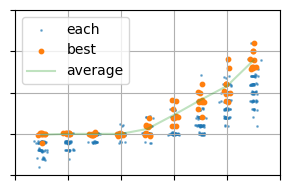

In [3]:
num_min = np.zeros((9, 10))
for i in range(9):
    for j in range(10):
        num_min[i, j] = save[i, j, :, 0][save[i, j, :, 1].argmin()]
num_all = save[:, :, :, 0].reshape(10, -1)
plt.figure(figsize=(3, 2))
for i in range(9):
    if i == 0:
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=90), num_all[i] + np.random.normal(loc=0, scale=0.08, size=90), s=1, alpha=0.5, c="C0", label="each")
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1", label="best")
    else:
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=90), num_all[i] + np.random.normal(loc=0, scale=0.08, size=90), s=1, alpha=0.5, c="C0")
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1")
plt.plot(np.arange(1, 10)/10, num_min.mean(axis=1), alpha=0.3, c="C2", label="average")
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 20)
plt.yticks([0, 5, 10, 15, 20])
plt.tick_params(labelleft=False, labelbottom=False)
plt.grid()
plt.tight_layout()
plt.savefig("figures/fig1/fig1f.png")

In [4]:
save = np.zeros((10, 10, 10, 2))
for ki in range(1, 11):
    for si in range(10):
        if ki < 3 or (ki == 3 and si < 6):
            continue
        x = igpu.open_csv_nonull("t3000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t3000_seed" + str(si + (ki - 1) * 10) + ".csv")
        w_save = None
        h_save = None
        k_save = None
        cost_min = np.inf
        for i in range(10):
            model = igpu.solve(x.T, 20, 50, z_th=x.min(), random_seed=i*100+(ki-1)*10+si, corr_max=0.3, comp_rate=0.1, Wlim=0.01, Hlim=1.0)
            c = model.reconstruction_cost()
            save[ri-1, si, i, :] = [model.k, c]
            print("corr=0.3, data_id={:d}, iter={:d} | real_K={:d}, pred_K={:d}, recon_err={:.1f}".format(int((ki-1)*10+si), i, ki, model.k, c))
            if c < cost_min:
                cost_min = c
                w_save = model.W.copy()
                h_save = model.H.copy()
                k_save = model.k
        np.savetxt("t3000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t3000_seed" + str(si + (ki - 1) * 10) + "_corrfix3_Wilm001_H.csv", cp.asnumpy(h_save).T, delimiter=",")
        for wi in range(k_save):
            np.savetxt("t3000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t3000_seed" + str(si + (ki - 1) * 10) + "_corrfix3_Wlim001_W" + str(wi) + ".csv", cp.asnumpy(w_save[:, wi, :]), delimiter=",")

corr=0.3, data_id=0, iter=0 | real_K=1, pred_K=1, recon_err=47108.0
corr=0.3, data_id=0, iter=1 | real_K=1, pred_K=1, recon_err=134403.0
corr=0.3, data_id=0, iter=2 | real_K=1, pred_K=1, recon_err=197534.7
corr=0.3, data_id=0, iter=3 | real_K=1, pred_K=1, recon_err=1105320.0
corr=0.3, data_id=0, iter=4 | real_K=1, pred_K=1, recon_err=294578.8
corr=0.3, data_id=0, iter=5 | real_K=1, pred_K=1, recon_err=209660.7
corr=0.3, data_id=0, iter=6 | real_K=1, pred_K=1, recon_err=228187.8
corr=0.3, data_id=0, iter=7 | real_K=1, pred_K=1, recon_err=292061.9
corr=0.3, data_id=0, iter=8 | real_K=1, pred_K=1, recon_err=139243.7
corr=0.3, data_id=0, iter=9 | real_K=1, pred_K=1, recon_err=315215.9
corr=0.3, data_id=1, iter=0 | real_K=1, pred_K=1, recon_err=237758.7
corr=0.3, data_id=1, iter=1 | real_K=1, pred_K=1, recon_err=143207.9
corr=0.3, data_id=1, iter=2 | real_K=1, pred_K=1, recon_err=96419.1
corr=0.3, data_id=1, iter=3 | real_K=1, pred_K=1, recon_err=160498.7
corr=0.3, data_id=1, iter=4 | real_

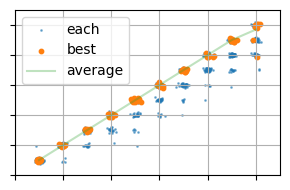

In [5]:
num_min = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        num_min[i, j] = save[i, j, :, 0][save[i, j, :, 1].argmin()]
num_all = save[:, :, :, 0].reshape(10, -1)
plt.figure(figsize=(3, 2))
for i in range(10):
    if i == 0:
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=100), num_all[i] + np.random.normal(loc=0, scale=0.08, size=100), s=1, alpha=0.5, c="C0", label="each")
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1", label="best")
    else:
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=100), num_all[i] + np.random.normal(loc=0, scale=0.08, size=100), s=1, alpha=0.5, c="C0")
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1")
plt.plot(np.arange(1, 11), num_min.mean(axis=1), alpha=0.3, c="C2", label="average")
plt.legend()
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.xticks([2*i for i in range(6)])
plt.yticks([2*i for i in range(6)])
plt.tick_params(labelleft=False, labelbottom=False)
plt.grid()
plt.tight_layout()
plt.savefig("figures/fig1/fig1g.png")

In [6]:
save = np.zeros((10, 10, 10, 2))
for ki in range(1, 11):
    for si in range(10):
        if ki < 3 or (ki == 3 and si < 6):
            continue
        x = igpu.open_csv_nonull("t3000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t3000_seed" + str(si + (ki - 1) * 10) + ".csv")
        w_save = None
        h_save = None
        k_save = None
        cost_min = np.inf
        for i in range(10):
            model = igpu.solve(x.T, 20, 50, z_th=x.min(), random_seed=i*100+(ki-1)*10+si, corr_max=0.3, comp_rate=0.1, Wlim=0.01, Hlim=1.0)
            c = model.reconstruction_cost()
            save[ri-1, si, i, :] = [model.k, c]
            print("corr=0.3, data_id={:d}, iter={:d} | real_K={:d}, pred_K={:d}, recon_err={:.1f}".format(int((ki-1)*10+si), i, ki, model.k, c))
            if c < cost_min:
                cost_min = c
                w_save = model.W.copy()
                h_save = model.H.copy()
                k_save = model.k
        np.savetxt("t3000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t3000_seed" + str(si + (ki - 1) * 10) + "_corrfix3_Wilm001_H.csv", cp.asnumpy(h_save).T, delimiter=",")
        for wi in range(k_save):
            np.savetxt("t3000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t3000_seed" + str(si + (ki - 1) * 10) + "_corrfix3_Wlim001_W" + str(wi) + ".csv", cp.asnumpy(w_save[:, wi, :]), delimiter=",")

corr=0.1, data_id=40, iter=0 | real_K=5, pred_K=3, recon_err=66548106.8
corr=0.1, data_id=40, iter=1 | real_K=5, pred_K=2, recon_err=84432169.1
corr=0.1, data_id=40, iter=2 | real_K=5, pred_K=3, recon_err=70987163.9
corr=0.1, data_id=40, iter=3 | real_K=5, pred_K=4, recon_err=37977086.6
corr=0.1, data_id=40, iter=4 | real_K=5, pred_K=3, recon_err=67809966.2
corr=0.1, data_id=40, iter=5 | real_K=5, pred_K=4, recon_err=32395919.0
corr=0.1, data_id=40, iter=6 | real_K=5, pred_K=2, recon_err=98788628.8
corr=0.1, data_id=40, iter=7 | real_K=5, pred_K=5, recon_err=5729116.2
corr=0.1, data_id=40, iter=8 | real_K=5, pred_K=2, recon_err=97655838.2
corr=0.1, data_id=40, iter=9 | real_K=5, pred_K=2, recon_err=80848001.4
corr=0.1, data_id=41, iter=0 | real_K=5, pred_K=4, recon_err=38945705.7
corr=0.1, data_id=41, iter=1 | real_K=5, pred_K=2, recon_err=79946738.6
corr=0.1, data_id=41, iter=2 | real_K=5, pred_K=3, recon_err=79850365.0
corr=0.1, data_id=41, iter=3 | real_K=5, pred_K=4, recon_err=3390

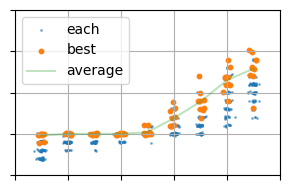

In [7]:
num_min = np.zeros((9, 10))
for i in range(9):
    for j in range(10):
        num_min[i, j] = save[i, j, :, 0][save[i, j, :, 1].argmin()]
num_all = save[:, :, :, 0].reshape(10, -1)
plt.figure(figsize=(3, 2))
for i in range(9):
    if i == 0:
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=90), num_all[i] + np.random.normal(loc=0, scale=0.08, size=90), s=1, alpha=0.5, c="C0", label="each")
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1", label="best")
    else:
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=90), num_all[i] + np.random.normal(loc=0, scale=0.08, size=90), s=1, alpha=0.5, c="C0")
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1")
plt.plot(np.arange(1, 10)/10, num_min.mean(axis=1), alpha=0.3, c="C2", label="average")
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 20)
plt.yticks([0, 5, 10, 15, 20])
plt.tick_params(labelleft=False, labelbottom=False)
plt.grid()
plt.tight_layout()
plt.savefig("figures/figs1/figs1a.png")

In [8]:
save = np.zeros((10, 10, 10, 2))
for ki in range(1, 11):
    for si in range(10):
        x = igpu.open_csv_nonull("t30000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t30000_seed" + str(si + (ki - 1) * 10 + 100) + ".csv")
        w_save = None
        h_save = None
        k_save = None
        cost_min = np.inf
        for i in range(10):
            model = igpu.solve(x.T, 20, 50, z_th=x.min(), random_seed=i*100+(ki-1)*10+si, corr_max=0.3, comp_rate=0.1, Wlim=0.01, Hlim=1.0)
            c = model.reconstruction_cost()
            save[ri-1, si, i, :] = [model.k, c]
            print("corr=0.3, data_id={:d}, iter={:d} | real_K={:d}, pred_K={:d}, recon_err={:.1f}".format(int((ki-1)*10+si), i, ki, model.k, c))
            if c < cost_min:
                cost_min = c
                w_save = model.W.copy()
                h_save = model.H.copy()
                k_save = model.k
        np.savetxt("t30000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t30000_seed" + str(si + (ki - 1) * 10 + 100) + "_corrfix3_Wilm001_H.csv", cp.asnumpy(h_save).T, delimiter=",")
        for wi in range(k_save):
            np.savetxt("t30000/gen_n" + str(ki) + "00_k" + str(ki) + "_l50_t30000_seed" + str(si + (ki - 1) * 10 + 100) + "_corrfix3_Wlim001_W" + str(wi) + ".csv", cp.asnumpy(w_save[:, wi, :]), delimiter=",")

corr=0.3, data_id=0, iter=0 | real_K=1, pred_K=1, recon_err=10957592.2
corr=0.3, data_id=0, iter=1 | real_K=1, pred_K=1, recon_err=8206747.0
corr=0.3, data_id=0, iter=2 | real_K=1, pred_K=1, recon_err=12805488.5
corr=0.3, data_id=0, iter=3 | real_K=1, pred_K=1, recon_err=3444503.7
corr=0.3, data_id=0, iter=4 | real_K=1, pred_K=1, recon_err=2835858.0
corr=0.3, data_id=0, iter=5 | real_K=1, pred_K=1, recon_err=17022136.0
corr=0.3, data_id=0, iter=6 | real_K=1, pred_K=1, recon_err=1321118.3
corr=0.3, data_id=0, iter=7 | real_K=1, pred_K=1, recon_err=2671306.9
corr=0.3, data_id=0, iter=8 | real_K=1, pred_K=1, recon_err=4848345.0
corr=0.3, data_id=0, iter=9 | real_K=1, pred_K=1, recon_err=2584215.8
corr=0.3, data_id=1, iter=0 | real_K=1, pred_K=1, recon_err=3593612.5
corr=0.3, data_id=1, iter=1 | real_K=1, pred_K=1, recon_err=2837431.4
corr=0.3, data_id=1, iter=2 | real_K=1, pred_K=1, recon_err=10347002.1
corr=0.3, data_id=1, iter=3 | real_K=1, pred_K=1, recon_err=5360611.2
corr=0.3, data_i

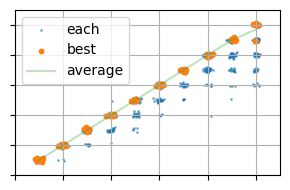

In [9]:
num_min = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        num_min[i, j] = save[i, j, :, 0][save[i, j, :, 1].argmin()]
num_all = save[:, :, :, 0].reshape(10, -1)
plt.figure(figsize=(3, 2))
for i in range(10):
    if i == 0:
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=100), num_all[i] + np.random.normal(loc=0, scale=0.08, size=100), s=1, alpha=0.5, c="C0", label="each")
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1", label="best")
    else:
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=100), num_all[i] + np.random.normal(loc=0, scale=0.08, size=100), s=1, alpha=0.5, c="C0")
        plt.scatter(np.random.normal(loc=i+1, scale=0.08, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1")
plt.plot(np.arange(1, 11), num_min.mean(axis=1), alpha=0.3, c="C2", label="average")
plt.legend()
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.xticks([2*i for i in range(6)])
plt.yticks([2*i for i in range(6)])
plt.tick_params(labelleft=False, labelbottom=False)
plt.grid()
plt.tight_layout()
plt.savefig("figures/figs1/figs1b.png")